Malaika
23-NTU-CS-1291
LAB5(1291)

In [2]:
#Importing Libraries

import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [4]:
#Dataset Loading
data = pd.read_csv("mushrooms.csv")
# Display first few rows
print("Dataset Loaded Successfully")
print(data.head())


Dataset Loaded Successfully
  class cap-shape cap-surface cap-color bruises odor gill-attachment  \
0     p         x           s         n       t    p               f   
1     e         x           s         y       t    a               f   
2     e         b           s         w       t    l               f   
3     p         x           y         w       t    p               f   
4     e         x           s         g       f    n               f   

  gill-spacing gill-size gill-color  ... stalk-surface-below-ring  \
0            c         n          k  ...                        s   
1            c         b          k  ...                        s   
2            c         b          n  ...                        s   
3            c         n          n  ...                        s   
4            w         b          k  ...                        s   

  stalk-color-above-ring stalk-color-below-ring veil-type veil-color  \
0                      w                      w     

In [5]:
#  Check  missing values
print("Missing Values in dataset are:")
print(data.isnull().sum())

Missing Values in dataset are:
class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64


In [12]:
#Feature Selection
print(f"Dataset shape: {data.shape}")
print(f"Target distribution:\n{data['class'].value_counts()}")



Dataset shape: (8124, 23)
Target distribution:
class
e    4208
p    3916
Name: count, dtype: int64


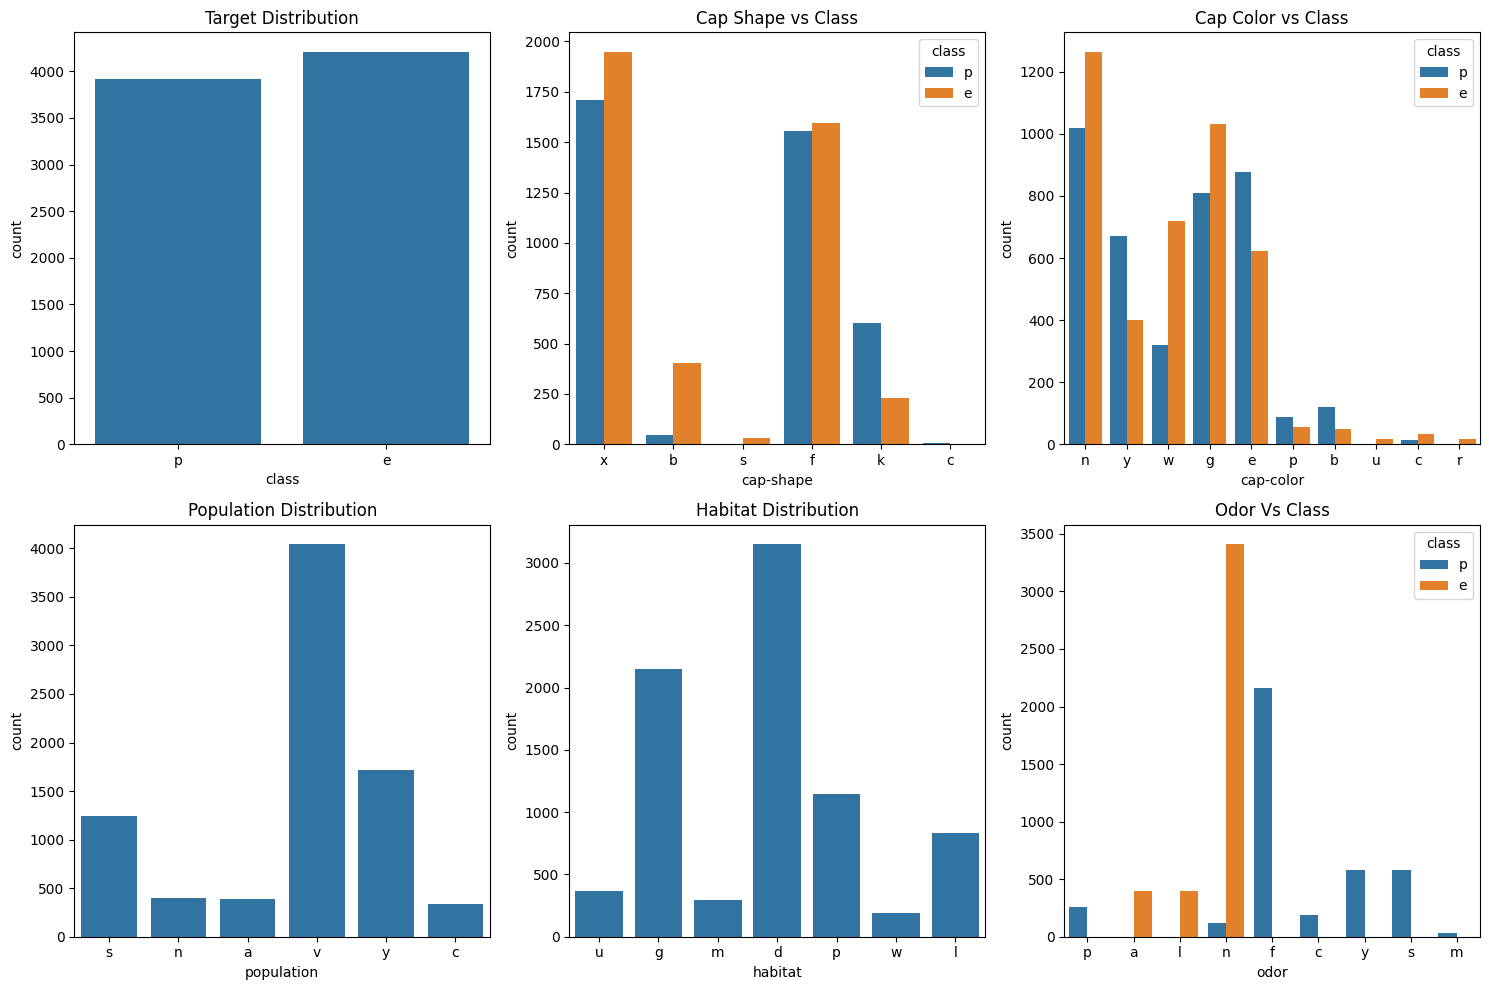

In [20]:
#Plotting and Visualization
plt.figure(figsize=(15, 10))
plt.subplot(2, 3, 1)
sns.countplot(data=data, x='class')
plt.title('Target Distribution')
plt.subplot(2, 3, 2)
sns.countplot(data=data, x='cap-shape', hue='class')
plt.title('Cap Shape vs Class')
plt.subplot(2, 3, 3)
sns.countplot(data=data, x='cap-color', hue='class')
plt.title('Cap Color vs Class')
import seaborn as sns
plt.rcParams['figure.figsize']=(10,8)
plt.subplot(2,3,4)
sns.countplot(data=data,x='population')
plt.title("Population Distribution")
plt.subplot(2,3,5)
sns.countplot(data=data,x='habitat')
plt.title("Habitat Distribution")
plt.subplot(2,3,6)
sns.countplot(data=data,x='odor',hue='class')
plt.title("Odor Vs Class")
plt.tight_layout()
plt.show()


In [24]:
#Data Preprocessing
from sklearn.preprocessing import OrdinalEncoder
#  Handle missing values
data = data.dropna()
# Separate features and target
mushroom_features = data.drop('class', axis=1)
mushroom_labels = data['class']
# Encode categorical features
encoder = OrdinalEncoder()
mushroom_prepared =  encoder.fit_transform(mushroom_features)
mushroom_prep_df = pd.DataFrame(mushroom_prepared, 
columns=mushroom_features.columns)


In [27]:
#KMEANS CLUSTERING
# Creation and fitting of model
clust = KMeans(n_clusters=2, random_state=42)

clust.fit(mushroom_prep_df)

#  results
k_labels = clust.labels_


In [31]:
# Map true labels to numerical values
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
Map = {'e': 0, 'p': 1}
true_labels = mushroom_labels.map(Map)
# Model Evaluation
accuracy = accuracy_score(true_labels, k_labels)
print(f"KMeans Accuracy: {accuracy:.4f}")


KMeans Accuracy: 0.7090


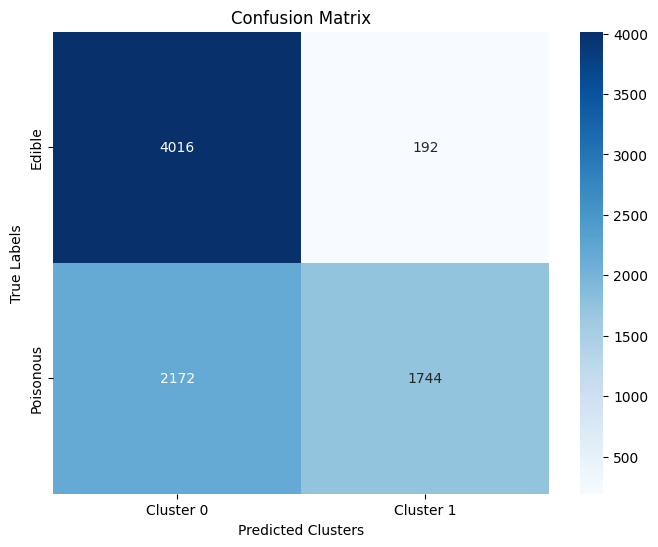

In [33]:
#Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(true_labels, k_labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Cluster 0', 'Cluster 1'],
            yticklabels=['Edible', 'Poisonous'])

plt.title('Confusion Matrix')
plt.xlabel('Predicted Clusters')
plt.ylabel('True Labels')
plt.show()


In [34]:
# Classification report
print("\nClassification Report:")
print(classification_report(true_labels, k_labels, target_names=['Edible', 'Poisonous']))



Classification Report:
              precision    recall  f1-score   support

      Edible       0.65      0.95      0.77      4208
   Poisonous       0.90      0.45      0.60      3916

    accuracy                           0.71      8124
   macro avg       0.77      0.70      0.68      8124
weighted avg       0.77      0.71      0.69      8124



Unsupervised Learning

In [35]:
#Importing Libraries

import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [36]:
#Dataset Loading
data = pd.read_csv("mushrooms.csv")
# Display first few rows
print("Dataset Loaded Successfully")
print(data.head())


Dataset Loaded Successfully
  class cap-shape cap-surface cap-color bruises odor gill-attachment  \
0     p         x           s         n       t    p               f   
1     e         x           s         y       t    a               f   
2     e         b           s         w       t    l               f   
3     p         x           y         w       t    p               f   
4     e         x           s         g       f    n               f   

  gill-spacing gill-size gill-color  ... stalk-surface-below-ring  \
0            c         n          k  ...                        s   
1            c         b          k  ...                        s   
2            c         b          n  ...                        s   
3            c         n          n  ...                        s   
4            w         b          k  ...                        s   

  stalk-color-above-ring stalk-color-below-ring veil-type veil-color  \
0                      w                      w     

In [37]:
#  Check  missing values
print("Missing Values in dataset are:")
print(data.isnull().sum())

Missing Values in dataset are:
class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64


In [43]:
# Encode categorical features
from sklearn.preprocessing import LabelEncoder

e = {}
for col in data.columns:
    if data[col].dtype == 'object':
        le = LabelEncoder()
        data[col] = le.fit_transform(data[col])
        e[col] = le



In [44]:
# Apply K-Means Clustering
model = KMeans(n_clusters=4, random_state=42)
data['Cluster'] = model.fit_predict(data)


In [45]:
#  Display cluster centers and counts
print("\nCluster Centers:\n", model.cluster_centers_)
print("\nCluster Counts:\n", data['Cluster'].value_counts())



Cluster Centers:
 [[1.45843010e-01 3.31583837e+00 1.69252206e+00 3.40315838e+00
  7.83557826e-01 4.80213655e+00 9.36832327e-01 1.08221087e-01
  1.24477473e-01 8.94844403e+00 6.37250348e-01 9.89317232e-01
  1.89224338e+00 1.95633999e+00 5.65490014e+00 5.57315374e+00
  0.00000000e+00 1.91964700e+00 1.13562471e+00 3.62099396e+00
  3.50673479e+00 3.90106828e+00 9.13144450e-01]
 [9.23688394e-01 3.29729730e+00 2.46210917e+00 2.98198198e+00
  5.88235294e-02 5.61049285e+00 1.00000000e+00 2.54372019e-02
  9.15739269e-01 1.17647059e-01 9.15739269e-01 7.94912560e-03
  1.52941176e+00 1.52941176e+00 6.41494436e+00 6.41494436e+00
  0.00000000e+00 2.00000000e+00 1.08426073e+00 1.33545310e-01
  6.98410175e+00 3.80922099e+00 2.17859036e+00]
 [4.65022647e-01 3.22546553e+00 1.80271766e+00 8.52340211e+00
  4.52440866e-01 2.56919980e+00 1.00000000e+00 2.37544036e-01
  1.34876699e-01 5.01358832e+00 2.19426271e-01 1.70005033e+00
  1.47458480e+00 1.50276799e+00 5.80624056e+00 5.80624056e+00
  0.00000000e+00 

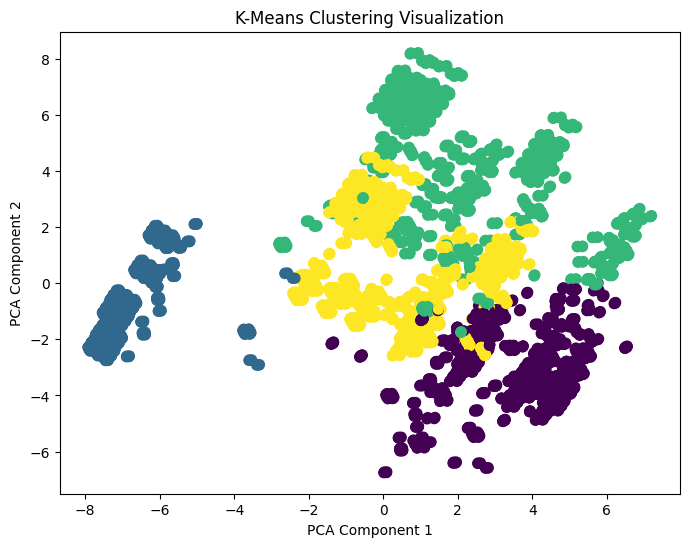

In [46]:
#  Visualize clusters using PCA (2D)
pca = PCA(n_components=2)
reduced_data = pca.fit_transform(data.drop('Cluster', axis=1))
plt.figure(figsize=(8,6))
plt.scatter(reduced_data[:,0], reduced_data[:,1], c=data['Cluster'], cmap='viridis', s=50)
plt.title('K-Means Clustering Visualization')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()


Activity

In [47]:
#Importing Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans,DBSCAN
from sklearn.metrics import silhouette_score

In [50]:
#Load Dataset
df=pd.read_csv("Mall_Customers (1).csv")
print("Data Loaded Successfully")
df.head(5)

Data Loaded Successfully


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [51]:
#Feature Selection
X=df[['Annual Income (k$)','Spending Score (1-100)']]
#Scale Features
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

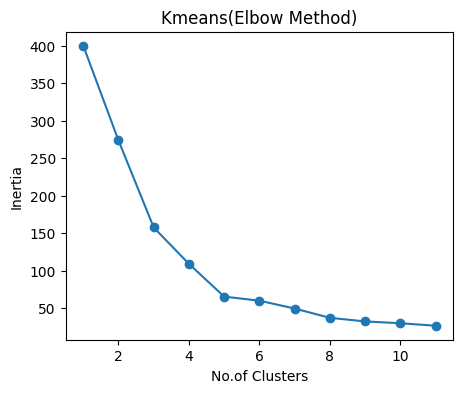

In [52]:
#Applying Kmean Algorithm
WCSS=[]
Range=range(1,12)
for k in Range:
    kmeans=KMeans(n_clusters=k,random_state=42)
    kmeans.fit(X_scaled)
    WCSS.append(kmeans.inertia_)
#Plotting
plt.figure(figsize=(5,4))
plt.title("Kmeans(Elbow Method)")
plt.plot(Range,WCSS,marker='o')
plt.xlabel("No.of Clusters")
plt.ylabel("Inertia")
plt.show()

In [53]:
#Prediction for Optimal no (6) of cluster 
kmeans=KMeans(n_clusters=6,random_state=42)
df["Optimal Cluster"]=kmeans.fit_predict(X_scaled)
df.head(5)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Optimal Cluster
0,1,Male,19,15,39,5
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,5


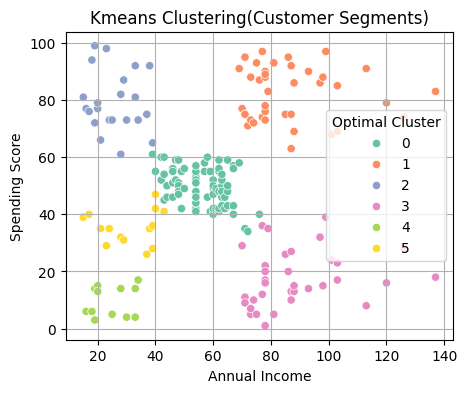

In [54]:
#Clusters Visualization
plt.figure(figsize=(5,4))
plt.title("Kmeans Clustering(Customer Segments)")
sns.scatterplot(x='Annual Income (k$)',y='Spending Score (1-100)',hue='Optimal Cluster',data=df,palette='Set2')
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.grid(True)
plt.show()


In [55]:
#Apllying DBSCAN
dbscan=DBSCAN(eps=0.5,min_samples=7)
df['DBSCAN Cluster']=dbscan.fit_predict(X_scaled)
df.head(5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Optimal Cluster,DBSCAN Cluster
0,1,Male,19,15,39,5,0
1,2,Male,21,15,81,2,0
2,3,Female,20,16,6,4,0
3,4,Female,23,16,77,2,0
4,5,Female,31,17,40,5,0


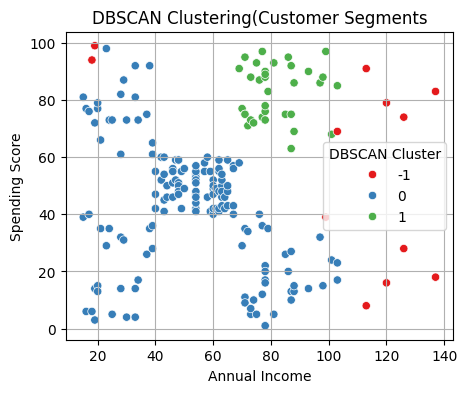

In [56]:
#Visualize DBSCAN Cluster
plt.figure(figsize=(5,4))
plt.title("DBSCAN Clustering(Customer Segments")
sns.scatterplot(x='Annual Income (k$)',y='Spending Score (1-100)',hue='DBSCAN Cluster',data=df,palette='Set1')
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.grid(True)
plt.show()
